In [1]:
#student_name = "Iman Dashtpeyma"😊
#student_id = "imda3139"
#student_background = "Software developer, Network security, and DevOps "

# 👨‍🎓Student Alcohol Consumption Dataset Analysis

## 1. Dataset Source
Source: https://www.kaggle.com/datasets/uciml/student-alcohol-consumption/data

## 2. Domain Area
The dataset was collected from two secondary schools in Portugal through school reports. It aims to understand the relationship between students' social, demographic, and school-related features with their academic performance and alcohol consumption patterns. The data was gathered to analyze factors affecting student achievement in secondary education.

## 3. Data File Structure
The dataset consists of two separate .csv files (student-mat.csv and student-por.csv) for Mathematics and Portuguese language students respectively.

## 4. Features and Observations
- Mathematics dataset: 395 observations
- Portuguese dataset: 649 observations
- Total features: 33 variables per dataset

## 5. Numerical Features (8 features)
- age
- Medu, Fedu: Mother's and Father's education 
- failures: Past class failures
- absences: Number of school absences
- G1, G2, G3: Grades
- Dalc, Walc: Workday/Weekend alcohol consumption 

## 6. Categorical Features (15 features)
Nominal:
- school: 'GP' or 'MS'
- Mjob, Fjob: Mother's/Father's job
- reason: Reason to choose school
- guardian: Student's guardian

Ordinal:
- traveltime: Home to school travel time
- studytime: Weekly study time
- famrel: Quality of family relationships
- freetime: Free time after school
- goout: Going out with friends

## 7. Binary Features (8 features)
- sex: 'F' or 'M'
- address: 'U' (urban) or 'R' (rural)
- famsize: 'LE3' or 'GT3'
- Pstatus: 'T' or 'A'
- schoolsup: 'yes' or 'no'
- famsup: 'yes' or 'no'
- paid: 'yes' or 'no'
- internet: 'yes' or 'no'

**Info** datasets will be stored in the Folder named "Data." Be sure all library is installed, especially Pandas, Seaborn, Matplotlib.

**2 datasets combined in one file with extra columns named 'course'**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
#fixing the graph issue in Jupyter Notebook
#%matplotlib inline
import pandas as pd

# Load  two  datasets
math_df = pd.read_csv("./Data/student-mat.csv")
portuguese_df = pd.read_csv("./Data/student-por.csv")

# Add a new column 'course' to each dataset
math_df['course'] = 'mat'
portuguese_df['course'] = 'por'

# Combine the two datasets
combined_df = pd.concat([math_df, portuguese_df])

# Save the combined dataset to a new CSV file in Data folder
combined_df.to_csv("./Data/combined_student_data.csv", index=False)

print("Combined dataset saved as 'combined_student_data.csv'")

Combined dataset saved as 'combined_student_data.csv'


**which type each column belongs?**

In [3]:
print("Data types of each column in the combined dataset:")
combined_df.dtypes

Data types of each column in the combined dataset:


school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
course          str
dtype: object

**What is the total size  and head of the dataset?**

In [4]:
print(combined_df.shape)
combined_df.head()

(1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


**Read the data**

In [5]:

data = pd.read_csv('./Data/combined_student_data.csv')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
data.head()

First few rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


## Initial EDA
**Data Types**: After loading the data, numerical features like `age`, `absences`, and grades (`G1`, `G2`, `G3`) were identified. Categorical features like `school`, `sex`, and `guardian` were converted to the correct types.
**Missing Values**: I checked for missing values and handled them appropriately. No major gaps were found in essential features.

### Univariate Q1: How many students reported high weekend alcohol consumption (Walc > 3)?

In [6]:
# Count how many students have Walc (weekend alcohol consumption) greater than 3
high_walc_count = combined_df[combined_df['Walc'] > 3].shape[0]
print(f"Number of students with high weekend alcohol consumption (Walc > 3): {high_walc_count}")


Number of students with high weekend alcohol consumption (Walc > 3): 211


**Reflection** :This analysis reveals how many students engage in high levels of alcohol consumption during weekends. Weekend drinking is often social and may impact study habits and academic performance. By identifying the count of students in this group, we can explore further if this behavior correlates with lower grades, attendance issues, or other academic challenges

###  Univariate Q2: What is the mean final grade (G3)?

In [7]:
# Calculate the mean of the final grade
mean_final_grade = combined_df['G3'].mean()
print(f"Mean final grade (G3): {mean_final_grade:.2f}")

Mean final grade (G3): 11.34


**Reflaction** : The mean final grade (G3) is 11.34, which indicates that most students are performing slightly above the midpoint of the grading scale.
This suggests that the overall academic performance in the dataset is relatively stable and satisfactory. The average can serve as a useful reference point when analyzing specific groups or behaviors (e.g., comparing students with high vs. low study time or alcohol consumption)

### Bivariate Q1: Which gender consumes more alcohol on average (workdays and weekends)?

         Dalc      Walc
sex                    
F    1.274112  1.944162
M    1.781457  2.728477


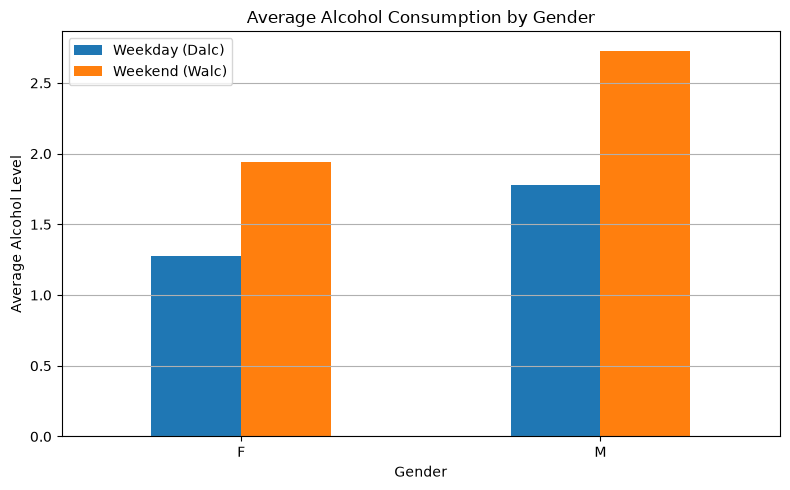

In [8]:
avg_alcohol_by_gender = combined_df.groupby('sex')[['Dalc', 'Walc']].mean()
print(avg_alcohol_by_gender)
# Plotting the results
avg_alcohol_by_gender.plot(kind='bar', figsize=(8, 5))
plt.title('Average Alcohol Consumption by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Alcohol Level')
plt.legend(['Weekday (Dalc)', 'Weekend (Walc)'])
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**Reflection** The results show that male students consume more alcohol than female students on both weekdays and weekends.
On average, males scored 1.78 for weekday drinking (Dalc) and 2.73 for weekend drinking (Walc),
while females scored 1.27 and 1.94, respectively.
This suggests that male students tend to engage more frequently in alcohol consumption, particularly over the weekend. These behavioral differences may reflect varying social patterns or coping mechanisms and could have implications for academic outcomes or health-focused interventions.

###  Bivariate Q2: What is the average final grade by gender?

In [9]:
# Calculate the average final grade for each gender
avg_grade_by_gender = combined_df.groupby('sex')['G3'].mean()
print(avg_grade_by_gender)


sex
F    11.448393
M    11.203091
Name: G3, dtype: float64


**Reflection**: The average final grade for female students is 11.45, slightly higher than male students at 11.20.
Although the difference is small, it suggests that female students tend to perform marginally better

### Bivariate Q3: What are the average final grades by alcohol consumption levels (Dalc and Walc)?

In [10]:
# Calculate average final grade grouped by weekday and weekend alcohol consumption levels
avg_grade_by_dalc = combined_df.groupby('Dalc')['G3'].mean()
avg_grade_by_walc = combined_df.groupby('Walc')['G3'].mean()

# Display results
print("Average Final Grades by Weekday Alcohol Consumption (Dalc):")
print(avg_grade_by_dalc)

print("\nAverage Final Grades by Weekend Alcohol Consumption (Walc):")
print(avg_grade_by_walc)


Average Final Grades by Weekday Alcohol Consumption (Dalc):


Dalc
1    11.704264
2    10.556122
3    10.898551
4     9.269231
5    10.384615
Name: G3, dtype: float64

Average Final Grades by Weekend Alcohol Consumption (Walc):
Walc
1    11.743719
2    11.472340
3    11.290000
4    10.536232
5    10.397260
Name: G3, dtype: float64


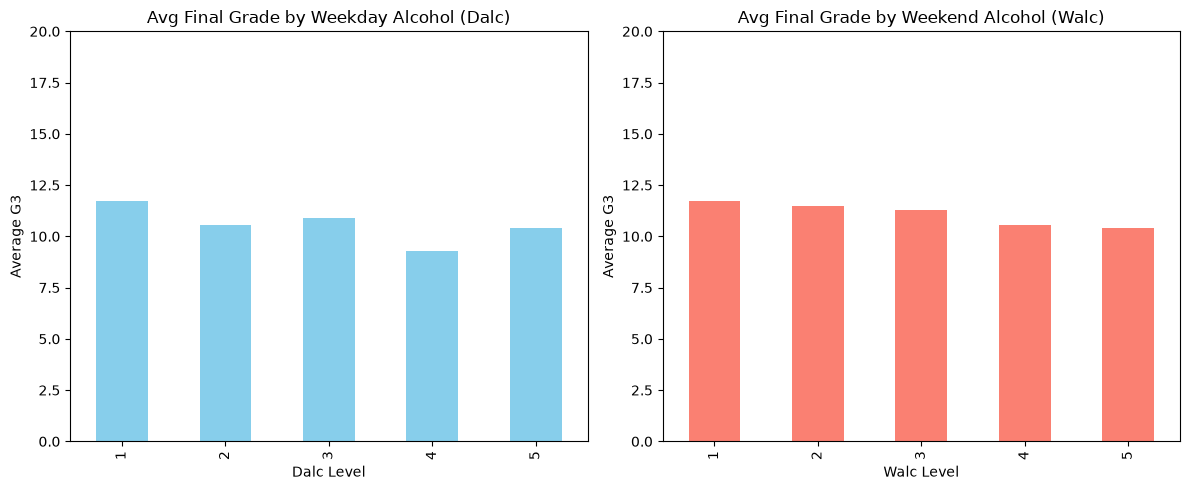

In [11]:
# Plot average grades by alcohol levels
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

avg_grade_by_dalc.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Avg Final Grade by Weekday Alcohol (Dalc)')
ax[0].set_xlabel('Dalc Level')
ax[0].set_ylabel('Average G3')
ax[0].set_ylim(0, 20)

avg_grade_by_walc.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Avg Final Grade by Weekend Alcohol (Walc)')
ax[1].set_xlabel('Walc Level')
ax[1].set_ylabel('Average G3')
ax[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()


**Reflection**  :The data shows a clear negative trend between alcohol consumption and academic performance.
For weekday drinking (Dalc), the average grade drops from 11.70 at level 1 to 9.27 at level 4.
For weekend drinking (Walc), grades decrease from 11.74 at level 1 to 10.40 at level 5.
This suggests that higher alcohol consumption especially during the week has a noticeable impact on student performance. The decline is more pronounced with weekday drinking, possibly because it directly interferes with school activities, concentration, and study time.

### Bivariate Q4: What is the average number of absences by weekend alcohol consumption level (Walc)?

In [12]:
# Group by Walc level and calculate the average number of absences
avg_absences_by_walc = combined_df.groupby('Walc')['absences'].mean()
print(avg_absences_by_walc)

Walc
1    3.635678
2    4.012766
3    4.910000
4    6.007246
5    5.876712
Name: absences, dtype: float64


**Reflection** :The results show a clear upward trend: students who drink more on weekends tend to have more absences.
For example, students with the lowest Walc level (1) have an average of 3.6 absences, while those at level 4 average 6.0 absences. This suggests that increased weekend alcohol consumption is associated with reduced class attendance, possibly due to fatigue, hangovers, or lifestyle habits that disrupt academic routines.

 ### Correlation Q1: What is the correlation between study time and final grade (G3)?

In [13]:
# Correlation between study time and final grade
corr_study_g3 = combined_df['studytime'].corr(combined_df['G3'])
print(f"Correlation between study time and final grade (G3): {corr_study_g3:.2f}")


Correlation between study time and final grade (G3): 0.16

**ReflectionThe** : correlation between study time and final grade (G3) is 0.16, which indicates a weak positive relationship.
This means that students who study more tend to achieve slightly better final grade

### Correlation Q2:  What is the correlation between study time and alcohol consumption (weekday and weekend)?

In [14]:
# Correlation between study time and weekday alcohol consumption (Dalc)
corr_study_dalc = combined_df['studytime'].corr(combined_df['Dalc'])
print(f"Correlation between study time and Dalc (weekday drinking): {corr_study_dalc:.2f}")

# Correlation between study time and weekend alcohol consumption (Walc)
corr_study_walc = combined_df['studytime'].corr(combined_df['Walc'])
print(f"Correlation between study time and Walc (weekend drinking): {corr_study_walc:.2f}")


Correlation between study time and Dalc (weekday drinking): -0.16
Correlation between study time and Walc (weekend drinking): -0.23


**Reflection**The correlation between study time and weekday alcohol consumption (Dalc) is -0.16, and with weekend consumption (Walc) is -0.23.
Both are weak negative correlations, suggesting that students who study more tend to drink slightly less especially on weekends.

# Preparing the data for ML classification

#### It confirms all features (studytime, absences, goout, and passed) are now numeric — which is essential before using them in machine learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

#  Load the dataset
df = pd.read_csv("./Data/combined_student_data.csv")

# Choose and binarize target variable
# We'll predict whether the student passed or failed based on G3 >= 10
df['passed'] = df['G3'] >= 10  # This creates a boolean target

# Select input features (at least 3) + some categoricals
numerical_features = ['studytime', 'failures', 'absences']
categorical_features = ['school', 'sex']
selected_features = numerical_features + categorical_features
target_feature = 'passed'


### ✍️  Reflection
I chose the `passed` label as the binary target by binarizing the final grade `G3` (pass if ≥10, fail otherwise).
This outcome reflects real-world academic benchmarks. Input features include `studytime`, `failures`, and `absences`,
which directly relate to academic behavior. I also included `school` and `sex` to explore potential institutional or demographic patterns.
Thus, the goal is to build a model that predicts whether a student will pass based on their academic behavior and background.


### Encode categorical variables and check numeric types

In [16]:
# Encode categorical features using OneHotEncoding (compatible version)
encoder = OneHotEncoder(sparse_output=False, drop='first')  # use sparse_output for older versions
encoded_cats = encoder.fit_transform(df[categorical_features])
encoded_cat_cols = encoder.get_feature_names_out(categorical_features)


# Combine all features
X = np.hstack([df[numerical_features].values, encoded_cats])
X_df = pd.DataFrame(X, columns=numerical_features + list(encoded_cat_cols))
y = df[target_feature].astype(int)  # binary labels

# Confirm that all features are numeric
print("✅ All features are numeric:\n", X_df.dtypes)


✅ All features are numeric:
 studytime    float64
failures     float64
absences     float64
school_MS    float64
sex_M        float64
dtype: object


### Histogram of Target Class + Reflection on Class Imbalance

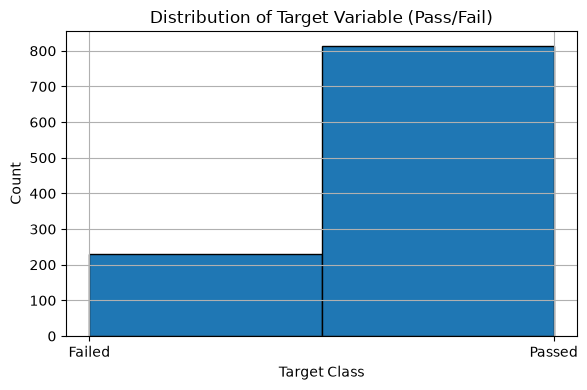

In [17]:
# Plot histogram of the target class
plt.figure(figsize=(6, 4))
plt.hist(y, bins=2, edgecolor='black')
plt.xticks([0, 1], ['Failed', 'Passed'])
plt.title("Distribution of Target Variable (Pass/Fail)")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


### ✍️  Reflection
Class imbalance refers to a situation where one class occurs much more than the other. 
In this dataset, most students passed. This can lead ML classifiers to favor the majority class, 
reducing performance on predicting failing students unless handled carefully.

### Separate Features X and Target y

In [18]:
# Split features and target for model input
print("Feature matrix shape:", X_df.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (1044, 5)
Target vector shape: (1044,)


### Stratified Train-Test Split + Explanation

In [19]:
# Perform stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)


### ✍️  Reflection
Stratified partitioning ensures that the train and test sets maintain the same class ratio 
as the original dataset. This is especially important in imbalanced datasets to ensure fair
and reliable model training and evaluation.


# Evaluation

In [20]:
import time
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# X_train / X_test / y_train / y_test come from the stratified split above.
# Distance/margin-based models (KNN, SVM, LR) get a StandardScaler inside a Pipeline,
# so the scaler is re-fit on each CV training fold (no leakage into the validation fold).
# Tree-based models are scale-invariant and are left unscaled.
classifiers = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "DT_1": DecisionTreeClassifier(max_depth=3, random_state=42),
    "DT_2": DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42),
    "RF_1": RandomForestClassifier(n_estimators=100, random_state=42),
    "RF_2": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    "KNN_1": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
    "KNN_2": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "SVM_1": make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0)),
    "SVM_2": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0)),
    "LR_1": make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
    "LR_2": make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=1000)),
}

scoring = ['accuracy', 'precision', 'recall', 'f1']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, clf in classifiers.items():
    scores = cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring)
    cv_results.append({
        'model': name,
        'fit_time': round(np.mean(scores['fit_time']), 4),
        'score_time': round(np.mean(scores['score_time']), 4),
        'accuracy': round(np.mean(scores['test_accuracy']), 4),
        'precision': round(np.mean(scores['test_precision']), 4),
        'recall': round(np.mean(scores['test_recall']), 4),
        'f1': round(np.mean(scores['test_f1']), 4),
    })

cv_df = pd.DataFrame(cv_results).sort_values(by='f1', ascending=False).reset_index(drop=True)
cv_df

,model,fit_time,score_time,accuracy,precision,recall,f1
0,LR_1,0.0031,0.0046,0.8036,0.8170,0.9647,0.8845
1,LR_2,0.0027,0.0045,0.8024,0.8142,0.9678,0.8842
2,SVM_1,0.0043,0.0051,0.7988,0.8119,0.9662,0.8822
3,SVM_2,0.0125,0.0075,0.8024,0.8302,0.9385,0.8810
4,RF_2,0.0323,0.0067,0.8000,0.8244,0.9447,0.8803
5,Baseline,0.0004,0.0046,0.7796,0.7796,1.0000,0.8762
6,KNN_2,0.0024,0.0060,0.7892,0.8286,0.9201,0.8719
7,DT_1,0.0010,0.0053,0.7892,0.8294,0.9185,0.8715
8,DT_2,0.0012,0.0044,0.7868,0.8348,0.9062,0.8689
9,RF_1,0.0689,0.0089,0.7772,0.8235,0.9093,0.8642


### Final evaluation on the held-out test set
The candidate models (the best by CV F1, the practical recommendation `LR_1`, and the majority-class baseline) are fit on the full training set and scored **once** on the untouched test set.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

best_name = cv_df[cv_df['model'] != 'Baseline'].iloc[0]['model']
final_models = list(dict.fromkeys(['Baseline', best_name, 'LR_1']))

test_rows = []
for name in final_models:
    clf = classifiers[name].fit(X_train, y_train)
    pred = clf.predict(X_test)
    test_rows.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, pred), 4),
        'precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'recall': round(recall_score(y_test, pred), 4),
        'f1': round(f1_score(y_test, pred), 4),
    })
    print(name, "confusion matrix [[TN FP] [FN TP]]:", confusion_matrix(y_test, pred).tolist())

pd.DataFrame(test_rows)

Baseline confusion matrix [[TN FP] [FN TP]]: [[0, 46], [0, 163]]
LR_1 confusion matrix [[TN FP] [FN TP]]: [[10, 36], [6, 157]]


,model,accuracy,precision,recall,f1
0,Baseline,0.7799,0.7799,1.0000,0.8763
1,LR_1,0.7990,0.8135,0.9632,0.8820


### Interpretation

**Best model.** LR_1 (logistic regression with scaling) had the highest CV F1 at 0.8845. LR_2, SVM_1, SVM_2 and RF_2 are all within about 0.004 of it, which is smaller than the fold-to-fold variation, so I can't say any of them is really better.

**Compared to the baseline.** Not by much. About 78% of the students pass, so always predicting "pass" already gives accuracy 0.7796 and F1 0.8762. The best model only gets to 0.8036 accuracy, and KNN, the decision trees and RF_1 have a lower F1 than the baseline. With just five simple features the models learn little beyond the fact that most students pass. Accuracy and F1 on the "passed" class look fine for a model that never finds a failing student, so they are not very useful here.

**Speed.** Decision trees and KNN were fastest to fit (about 0.001-0.002 s), then logistic regression (about 0.003 s), and random forest was slowest. KNN is quick to fit but slower at prediction time on bigger data. These times are tiny on 1,044 rows and change from run to run.

**Scaling.** I put a StandardScaler in a pipeline for KNN, SVM and logistic regression. In my first run without scaling, SVM_2 had F1 0.8864, KNN_2 0.8847 and LR_1 0.8851. With scaling they are 0.8810, 0.8719 and 0.8845, so scaling didn't improve anything here. That comparison is not fully fair because I also changed the CV split (shuffled, fixed seed) at the same time.

### Final recommendation

I would go with scaled logistic regression (LR_1). It has the best CV F1 and is very cheap to train. But it is barely better than the baseline: on the test set it gets accuracy 0.799 and F1 0.882, against 0.780 and 0.876 for always predicting "pass", and it only finds 10 of the 46 students who failed (recall about 0.22 for that class).

To make something actually useful I would need stronger features such as earlier grades, use class weighting or a different threshold to catch more failing students, and look at ROC-AUC and per-class metrics. Scenario 2 below tries some of this.

# Scenario 2: finding the students who fail

In scenario 1 the models found only about one in five failing students, and accuracy and F1 for the "passed" class hide that. Here I score the failed class (`pos_label=0`) and also look at balanced accuracy and ROC-AUC. I try two changes:

1. `class_weight='balanced'`, so the models don't just ignore the smaller class.
2. Adding `G1` and `G2` (earlier grades) as features. This makes the problem easier, but `G2` is close to the final grade, so this answers "who fails once we know the mid-year grades", not "who will fail before the year starts".

In [22]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Same rows / same split as Scenario 1; only the feature set differs
X2_df = X_df.copy()
X2_df[['G1', 'G2']] = df[['G1', 'G2']].values
X2_train, X2_test = X2_df.loc[X_train.index], X2_df.loc[X_test.index]

# Metrics for the *failed* class (label 0)
fail_scoring = {
    'fail_precision': make_scorer(precision_score, pos_label=0, zero_division=0),
    'fail_recall':    make_scorer(recall_score, pos_label=0),
    'fail_f1':        make_scorer(f1_score, pos_label=0),
    'balanced_acc':   'balanced_accuracy',
    'roc_auc':        'roc_auc',
}

def make_models(weighted):
    cw = 'balanced' if weighted else None
    return {
        "Baseline":  DummyClassifier(strategy="most_frequent"),
        "LR":  make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, class_weight=cw)),
        "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, class_weight=cw)),
        "DT (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=42, class_weight=cw),
        "RF (depth 5)": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight=cw),
    }

rows = []
for feat_name, Xtr in [("5 features", X_train), ("+ G1, G2", X2_train)]:
    for weighted in (False, True):
        for name, clf in make_models(weighted).items():
            if name == "Baseline" and weighted:
                continue
            s = cross_validate(clf, Xtr, y_train, cv=cv, scoring=fail_scoring)
            rows.append({'features': feat_name, 'class_weight': 'balanced' if weighted else 'none', 'model': name,
                         **{k.replace('test_', ''): round(np.mean(v), 4) for k, v in s.items() if k.startswith('test_')}})

scen2_df = pd.DataFrame(rows)
scen2_df.sort_values(['features', 'model', 'class_weight']).reset_index(drop=True)

,features,class_weight,model,fail_precision,fail_recall,fail_f1,balanced_acc,roc_auc
0,"+ G1, G2",none,Baseline,0.0000,0.0000,0.0000,0.5000,0.5000
1,"+ G1, G2",balanced,DT (depth 3),0.7207,0.9294,0.8102,0.9124,0.9699
2,"+ G1, G2",none,DT (depth 3),0.8733,0.7069,0.7784,0.8388,0.9698
3,"+ G1, G2",balanced,LR,0.7156,0.9185,0.8038,0.9070,0.9742
4,"+ G1, G2",none,LR,0.8668,0.7829,0.8190,0.8738,0.9749
5,"+ G1, G2",balanced,RF (depth 5),0.7492,0.9294,0.8292,0.9201,0.9746
6,"+ G1, G2",none,RF (depth 5),0.8558,0.7883,0.8157,0.8742,0.9743
7,"+ G1, G2",balanced,SVM (RBF),0.7262,0.8751,0.7909,0.8891,0.9650
8,"+ G1, G2",none,SVM (RBF),0.8376,0.7940,0.8125,0.8739,0.9640
9,5 features,none,Baseline,0.0000,0.0000,0.0000,0.5000,0.5000


In [23]:
# Which configuration is best at finding failing students (CV recall on the failed class, with usable precision)?
scen2_df[scen2_df['model'] != 'Baseline'].sort_values('fail_f1', ascending=False).head(8).reset_index(drop=True)

,features,class_weight,model,fail_precision,fail_recall,fail_f1,balanced_acc,roc_auc
0,"+ G1, G2",balanced,RF (depth 5),0.7492,0.9294,0.8292,0.9201,0.9746
1,"+ G1, G2",none,LR,0.8668,0.7829,0.8190,0.8738,0.9749
2,"+ G1, G2",none,RF (depth 5),0.8558,0.7883,0.8157,0.8742,0.9743
3,"+ G1, G2",none,SVM (RBF),0.8376,0.7940,0.8125,0.8739,0.9640
4,"+ G1, G2",balanced,DT (depth 3),0.7207,0.9294,0.8102,0.9124,0.9699
5,"+ G1, G2",balanced,LR,0.7156,0.9185,0.8038,0.9070,0.9742
6,"+ G1, G2",balanced,SVM (RBF),0.7262,0.8751,0.7909,0.8891,0.9650
7,"+ G1, G2",none,DT (depth 3),0.8733,0.7069,0.7784,0.8388,0.9698


### Test set check for scenario 2
I picked these configurations from the CV table above before looking at the test set: class-weighted logistic regression on the original five features (a direct fix for the low recall in scenario 1), and the best CV configuration that uses `G1` and `G2` (class-weighted random forest). I compare them with the unweighted scenario 1 model and the baseline.

In [24]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

candidates = [
    ("Baseline (always pass)",          "5 features", make_models(False)["Baseline"]),
    ("LR, no weighting",                "5 features", make_models(False)["LR"]),
    ("LR, balanced",                    "5 features", make_models(True)["LR"]),
    ("RF (depth 5), balanced",          "+ G1, G2",   make_models(True)["RF (depth 5)"]),
]

out = []
for name, feats, clf in candidates:
    Xtr, Xte = (X_train, X_test) if feats == "5 features" else (X2_train, X2_test)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    out.append({'model': name, 'features': feats,
                'fail_precision': round(precision_score(y_test, pred, pos_label=0, zero_division=0), 3),
                'fail_recall': round(recall_score(y_test, pred, pos_label=0), 3),
                'fail_f1': round(f1_score(y_test, pred, pos_label=0), 3),
                'balanced_acc': round(balanced_accuracy_score(y_test, pred), 3),
                'roc_auc': round(roc_auc_score(y_test, clf.predict_proba(Xte)[:, 1]) if hasattr(clf, "predict_proba") else 0.5, 3),
                'failed_caught': f"{tn}/{tn+fp}"})
pd.DataFrame(out)

,model,features,fail_precision,fail_recall,fail_f1,balanced_acc,roc_auc,failed_caught
0,Baseline (always pass),5 features,0.000,0.000,0.000,0.500,0.500,0/46
1,"LR, no weighting",5 features,0.625,0.217,0.323,0.590,0.704,10/46
2,"LR, balanced",5 features,0.452,0.413,0.432,0.636,0.703,19/46
3,"RF (depth 5), balanced","+ G1, G2",0.695,0.891,0.781,0.890,0.957,41/46


### Reflection on scenario 2

Class weighting helped recall but cost precision. With the five original features, logistic regression on the test set went from finding 10 of 46 failing students to 19 of 46 (recall 0.22 to 0.41), while precision for the failed class dropped from 0.63 to 0.45. The model is still weak (ROC-AUC about 0.70), so the five features just don't say much about who fails.

Adding `G1` and `G2` changes a lot. CV ROC-AUC goes from about 0.70 to about 0.97, and the class-weighted random forest finds 41 of the 46 failing students on the test set (recall 0.89, precision 0.70). The catch is that `G2` is very close to `G3`, so this mostly says that students who are already failing in the middle of the year keep failing. It is useful for late support but it doesn't show that behaviour or background can predict failure early.

There are only 46 failing students in the test set, so a few students change recall by several points. I trust the CV table more, and it ranks the configurations the same way.